In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from google.colab import drive
drive.mount('/content/drive')

In [28]:
fname = '/content/drive/MyDrive/resultphyschem.csv'

In [29]:
df = pd.read_csv(fname, low_memory=False)
print(df.shape)

(236428, 81)


In [30]:
df = df[df["CharacteristicName"].str.contains("nitrate", case=False, na=False)]

In [31]:
df = df[[
    "MonitoringLocationIdentifier",
    "ActivityStartDate",
    "ResultMeasureValue"
]]

In [32]:
df["ActivityStartDate"] = pd.to_datetime(df["ActivityStartDate"], errors="coerce")
df["ResultMeasureValue"] = pd.to_numeric(df["ResultMeasureValue"], errors="coerce")

In [33]:
df = df.dropna()
df = df[df["ResultMeasureValue"] >= 0]

In [34]:
lower = df["ResultMeasureValue"].quantile(0.01)
upper = df["ResultMeasureValue"].quantile(0.99)

df = df[df["ResultMeasureValue"].between(lower, upper)]

In [35]:
station_counts = df.groupby("MonitoringLocationIdentifier").size()
good_stations = station_counts[station_counts >= 24].index

df = df[df["MonitoringLocationIdentifier"].isin(good_stations)]

In [36]:
df = df.sort_values(["MonitoringLocationIdentifier", "ActivityStartDate"])

In [37]:
station_series = []

for station_id, group in df.groupby("MonitoringLocationIdentifier"):

    group = group.sort_values("ActivityStartDate")
    group = group.set_index("ActivityStartDate")

    ts = group["ResultMeasureValue"].resample("M").mean()

    if ts.dropna().shape[0] >= 24:
        station_series.append(ts)

/tmp/ipykernel_2746/2655626843.py:8: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  ts = group["ResultMeasureValue"].resample("M").mean()
/tmp/ipykernel_2746/2655626843.py:8: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  ts = group["ResultMeasureValue"].resample("M").mean()
/tmp/ipykernel_2746/2655626843.py:8: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  ts = group["ResultMeasureValue"].resample("M").mean()
/tmp/ipykernel_2746/2655626843.py:8: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  ts = group["ResultMeasureValue"].resample("M").mean()


In [38]:
X_data = []
y_data = []

window_size = 12

for series in station_series:

    series = series.dropna().values.reshape(-1, 1)

    if len(series) < window_size + 1:
        continue

    scaler = StandardScaler()
    series = scaler.fit_transform(series)

    for i in range(len(series) - window_size):
        X_data.append(series[i:i+window_size])
        y_data.append(series[i+window_size])

In [39]:
X = np.array(X_data)
y = np.array(y_data)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (13557, 12, 1)
y shape: (13557, 1)


In [40]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [41]:
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)

X_val = torch.tensor(X_val, dtype=torch.float32)
y_val = torch.tensor(y_val, dtype=torch.float32)

In [42]:
class LSTMModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(input_size=1, hidden_size=32, batch_first=True)
        self.fc = nn.Linear(32, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        return self.fc(out)

In [43]:
model = LSTMModel()
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [44]:
def mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

def r2(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - ss_res / ss_tot

In [45]:
for epoch in range(50):

    #train
    model.train()
    optimizer.zero_grad()

    train_pred = model(X_train)
    train_loss = criterion(train_pred, y_train)

    train_loss.backward()
    optimizer.step()

    train_pred_np = train_pred.detach().numpy()
    y_train_np = y_train.numpy()

    #valid
    model.eval()
    with torch.no_grad():
        val_pred = model(X_val)
        val_loss = criterion(val_pred, y_val)

        val_pred_np = val_pred.numpy()
        y_val_np = y_val.numpy()

    #print
    print(f"""
Epoch {epoch}
Train Loss: {train_loss.item():.4f} | Val Loss: {val_loss.item():.4f}
Train MAE: {mae(y_train_np, train_pred_np):.4f} | Val MAE: {mae(y_val_np, val_pred_np):.4f}
Train RMSE: {rmse(y_train_np, train_pred_np):.4f} | Val RMSE: {rmse(y_val_np, val_pred_np):.4f}
Train R2: {r2(y_train_np, train_pred_np):.4f} | Val R2: {r2(y_val_np, val_pred_np):.4f}
""")


Epoch 0
Train Loss: 1.0044 | Val Loss: 1.0140
Train MAE: 0.7332 | Val MAE: 0.7306
Train RMSE: 1.0022 | Val RMSE: 1.0070
Train R2: 0.0080 | Val R2: 0.0094


Epoch 1
Train Loss: 1.0025 | Val Loss: 1.0121
Train MAE: 0.7335 | Val MAE: 0.7309
Train RMSE: 1.0012 | Val RMSE: 1.0060
Train R2: 0.0099 | Val R2: 0.0113


Epoch 2
Train Loss: 1.0007 | Val Loss: 1.0103
Train MAE: 0.7339 | Val MAE: 0.7312
Train RMSE: 1.0003 | Val RMSE: 1.0051
Train R2: 0.0117 | Val R2: 0.0130


Epoch 3
Train Loss: 0.9990 | Val Loss: 1.0085
Train MAE: 0.7342 | Val MAE: 0.7313
Train RMSE: 0.9995 | Val RMSE: 1.0043
Train R2: 0.0134 | Val R2: 0.0148


Epoch 4
Train Loss: 0.9973 | Val Loss: 1.0068
Train MAE: 0.7344 | Val MAE: 0.7314
Train RMSE: 0.9987 | Val RMSE: 1.0034
Train R2: 0.0150 | Val R2: 0.0164


Epoch 5
Train Loss: 0.9957 | Val Loss: 1.0052
Train MAE: 0.7344 | Val MAE: 0.7313
Train RMSE: 0.9978 | Val RMSE: 1.0026
Train R2: 0.0166 | Val R2: 0.0180


Epoch 6
Train Loss: 0.9941 | Val Loss: 1.0036
Train MAE: 0.7343

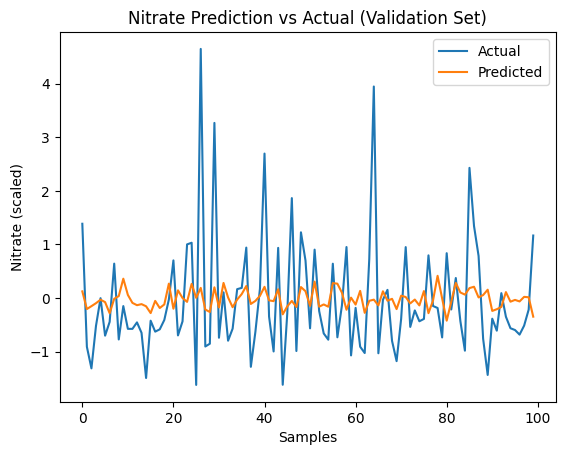

In [46]:
import matplotlib.pyplot as plt

model.eval()
with torch.no_grad():
    preds = model(X_val).numpy()
    true = y_val.numpy()

plt.figure()
plt.plot(true[:100], label="Actual")
plt.plot(preds[:100], label="Predicted")
plt.title("Nitrate Prediction vs Actual (Validation Set)")
plt.xlabel("Samples")
plt.ylabel("Nitrate (scaled)")
plt.legend()
plt.show()

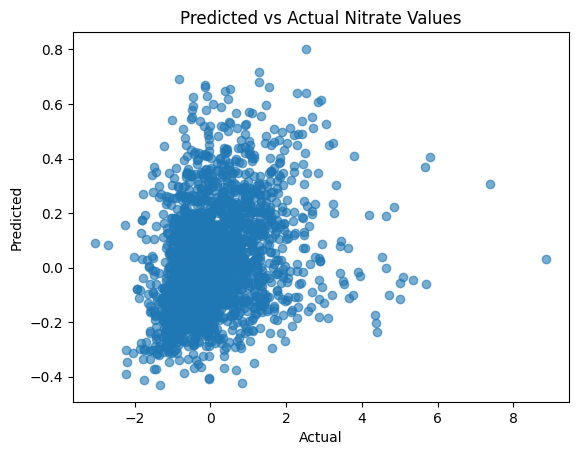

In [47]:
plt.figure()
plt.scatter(true, preds, alpha=0.6)
plt.title("Predicted vs Actual Nitrate Values")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()

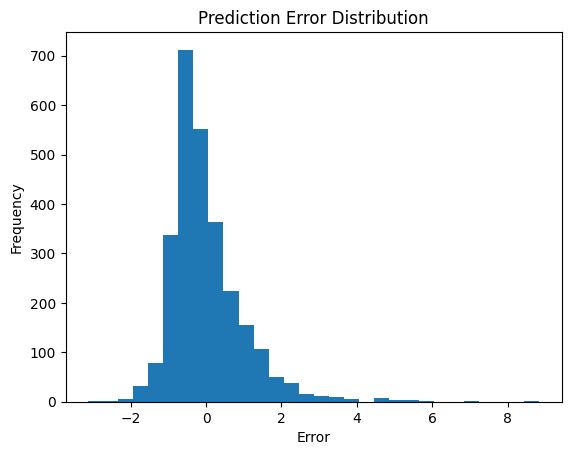

In [48]:
errors = true - preds

plt.figure()
plt.hist(errors, bins=30)
plt.title("Prediction Error Distribution")
plt.xlabel("Error")
plt.ylabel("Frequency")
plt.show()

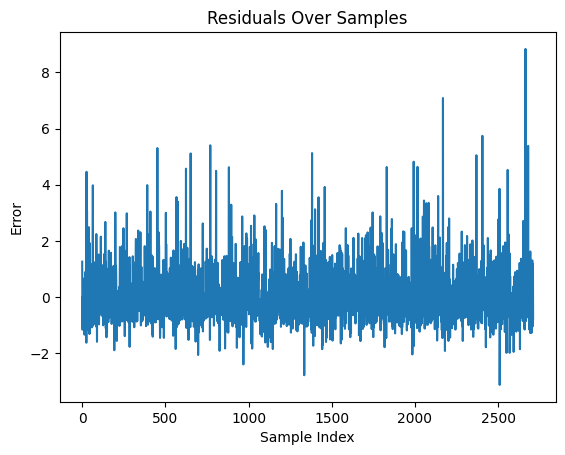

In [52]:
plt.figure()
plt.plot(errors)
plt.title("Residuals Over Samples")
plt.xlabel("Sample Index")
plt.ylabel("Error")
plt.show()